/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


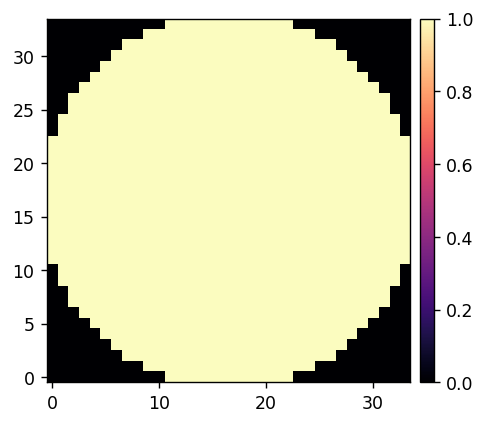

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, shmim_utils, coro_utils, telem

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 0.307

dm_mask = dm.create_mask(Nact=34, return_np=1)
utils.imshow([dm_mask])

In [3]:
data_path = Path(f'data/20251204-iefc-2')

In [ ]:
iefc_data = utils.load_pickle(data_path/'iefc_results.pkl')
iefc_data.keys()


dict_keys(['images', 'contrasts', 'commands', 'del_commands', 'pixelscale', 'dh_mask', 'probes'])

In [7]:
images = iefc_data['images']
contrasts = iefc_data['contrasts']
commands = iefc_data['commands']
dh_mask = iefc_data['dh_mask']
pxscl = iefc_data['pixelscale']

In [10]:
len(images)

17

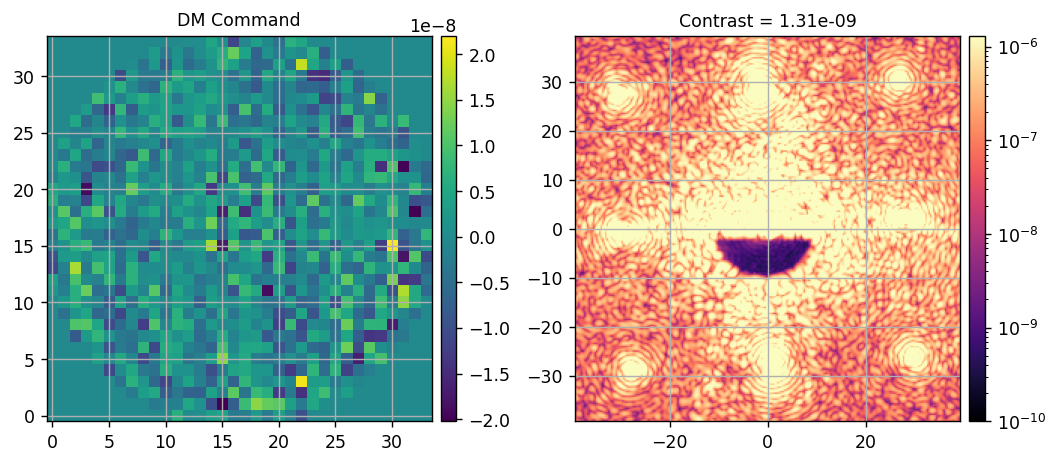

In [20]:
idx = 16

utils.imshow(
    [commands[idx], images[idx], ],
    titles=['DM Command', f'Contrast = {contrasts[idx]:.2e}'],
    cmaps=['viridis', 'magma'],
    norms=[None, LogNorm(1e-10)],
    pxscls=[None, pxscl],
    grids=[0, 1],
)